## Laboratorio 5
### Bayes Ingenuo

**Preparar el entorno**

In [22]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [23]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



### Actividades:

1. Elabore un modelo de regresión usando bayes ingenuo (naive bayes), el conjunto de entrenamiento y la variable respuesta “el precio”. Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las hojas anteriores para que los modelos sean comparables.

2. Analice los resultados del modelo de regresión usando bayes ingenuo. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.

3. Compare los resultados con el modelo de regresión lineal y el árbol de regresión que hizo
en las entregas pasadas. ¿Cuál funcionó mejor?

Resumen de metricas (menor MAE/RMSE y mayor R2 es mejor):
                             R2_log   MAE_USD   RMSE_USD
Modelo                                                  
Naive Bayes (discretizado)   0.1142  707.6901  4127.6267
Bayesian Ridge (referencia)  0.3705  610.9949  4091.0164
Baseline (mediana de train) -0.0160  653.3525  4354.9604

Analisis Actividad 2:
- Naive Bayes (discretizado) R2 en log_price: 0.1142
- Naive Bayes MAE: $707.69 | RMSE: $4,127.63 | MAPE: 86.95%
- Mejora vs baseline en MAE: -8.32%
- Mejora vs baseline en RMSE: 5.22%


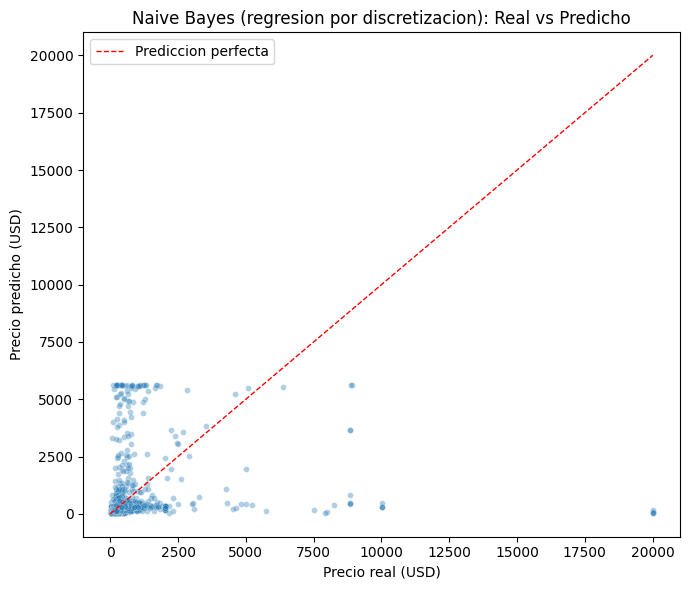

In [24]:
# Actividad 1: se aproxima regresion con Naive Bayes discretizando el target
# GaussianNB clasifica, por eso se convierte log_price en intervalos (bins)
n_bins = 10
y_train_bin, bin_edges = pd.qcut(
    y_train,
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates='drop'
 )
y_train_bin = pd.Series(y_train_bin, index=y_train.index).astype(int)

modelo_nb_reg = GaussianNB()
modelo_nb_reg.fit(X_train, y_train_bin)

# Se reconstruye una prediccion continua usando el valor esperado de los bins
proba_test = modelo_nb_reg.predict_proba(X_test)
bin_centers = {
    i: (bin_edges[i] + bin_edges[i + 1]) / 2
    for i in range(len(bin_edges) - 1)
}
centers_ordered = np.array([bin_centers[int(cls)] for cls in modelo_nb_reg.classes_])
y_pred_log_nb = proba_test @ centers_ordered

# Metricas en escala log
r2_nb_log = r2_score(y_test, y_pred_log_nb)
mae_nb_log = mean_absolute_error(y_test, y_pred_log_nb)
rmse_nb_log = np.sqrt(mean_squared_error(y_test, y_pred_log_nb))

# Metricas en dolares (escala original)
y_test_usd = np.exp(y_test)
y_pred_usd_nb = np.exp(y_pred_log_nb)
mae_nb_usd = mean_absolute_error(y_test_usd, y_pred_usd_nb)
rmse_nb_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_nb))
mape_nb = np.mean(np.abs((y_test_usd - y_pred_usd_nb) / y_test_usd)) * 100

# Baseline simple: se predice la mediana del train
baseline_log = np.full(len(y_test), y_train.median())
baseline_usd = np.exp(baseline_log)
r2_baseline_log = r2_score(y_test, baseline_log)
mae_baseline_usd = mean_absolute_error(y_test_usd, baseline_usd)
rmse_baseline_usd = np.sqrt(mean_squared_error(y_test_usd, baseline_usd))

# Como referencia, tambien se compara con BayesianRidge
modelo_bayes_reg = BayesianRidge()
modelo_bayes_reg.fit(X_train, y_train)
y_pred_log_bayes_ridge = modelo_bayes_reg.predict(X_test)
r2_bayes_ridge_log = r2_score(y_test, y_pred_log_bayes_ridge)
mae_bayes_ridge_usd = mean_absolute_error(y_test_usd, np.exp(y_pred_log_bayes_ridge))
rmse_bayes_ridge_usd = np.sqrt(mean_squared_error(y_test_usd, np.exp(y_pred_log_bayes_ridge)))

resultados = pd.DataFrame({
    'Modelo': [
        'Naive Bayes (discretizado)',
        'Bayesian Ridge (referencia)',
        'Baseline (mediana de train)'
    ],
    'R2_log': [r2_nb_log, r2_bayes_ridge_log, r2_baseline_log],
    'MAE_USD': [mae_nb_usd, mae_bayes_ridge_usd, mae_baseline_usd],
    'RMSE_USD': [rmse_nb_usd, rmse_bayes_ridge_usd, rmse_baseline_usd]
}).set_index('Modelo')

print('Resumen de metricas (menor MAE/RMSE y mayor R2 es mejor):')
print(resultados.round(4))

improv_mae_vs_base = (mae_baseline_usd - mae_nb_usd) / mae_baseline_usd * 100
improv_rmse_vs_base = (rmse_baseline_usd - rmse_nb_usd) / rmse_baseline_usd * 100

print('\nAnalisis Actividad 2:')
print(f'- Naive Bayes (discretizado) R2 en log_price: {r2_nb_log:.4f}')
print(f'- Naive Bayes MAE: ${mae_nb_usd:,.2f} | RMSE: ${rmse_nb_usd:,.2f} | MAPE: {mape_nb:.2f}%')
print(f'- Mejora vs baseline en MAE: {improv_mae_vs_base:.2f}%')
print(f'- Mejora vs baseline en RMSE: {improv_rmse_vs_base:.2f}%')

# Grafico real vs predicho (se recorta al p99 para que no se aplaste la nube)
plot_df = pd.DataFrame({
    'Real_USD': y_test_usd.values,
    'Pred_USD': y_pred_usd_nb
})
upper = np.percentile(plot_df['Real_USD'], 99)
plot_df = plot_df[(plot_df['Real_USD'] <= upper) & (plot_df['Pred_USD'] <= upper)]
plot_df = plot_df.sample(min(3000, len(plot_df)), random_state=42)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=18)
plt.plot([0, upper], [0, upper], 'r--', linewidth=1, label='Prediccion perfecta')
plt.title('Naive Bayes (regresion por discretizacion): Real vs Predicho')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()